# Numpy -  multidimensional data arrays

I am using the file created by Dr. J.R. Johansson (jrjohansson at gmail.com).

The latest version of his [IPython notebook](http://ipython.org/notebook.html) lecture is available at [http://github.com/jrjohansson/scientific-python-lectures](http://github.com/jrjohansson/scientific-python-lectures).

The other notebooks in this lecture series are indexed at [http://jrjohansson.github.io](http://jrjohansson.github.io).

This is the modified verios of Dr. J.R. Johansson's original numpy lecture.
I have tried to give the same treatment as the matplotlib lecture: extra notes on *why*, not just *what*; a self-contained synthetic dataset later on, so nothing here depends on a file you might not have; 
and a handful of asides tying things to the ABIDE / Neural-ODE / GNN work sitting on my own desk right now. 
Where I've changed or added something, it's called out explicitly, so Johansson's voice and mine stay easy to tell apart.

In [1]:
# what is this line all about?!? Answer in lecture 4
%matplotlib inline
import matplotlib.pyplot as plt

## Introduction

The `numpy` package (module) is used in almost all numerical computation using Python. It is a package that provide high-performance vector, matrix and higher-dimensional data structures for Python. It is implemented in C and Fortran so when calculations are vectorized (formulated with vectors and matrices), performance is very good. 

To use `numpy` you need to import the module, using for example:

In [2]:
from numpy import *

**A quick note before we go further.**

`from numpy import *` works, and you'll see it all over older tutorials — including, admittedly, the cell right above this one. It dumps every numpy name (`array`, `arange`, `dot`, even the constant `e`) straight into the notebook's namespace, so you can write `array([1,2,3])` instead of `np.array([1,2,3])`.

The trouble is the same trouble we ran into with `pylab` in the matplotlib lecture: it silently shadows Python's own builtins. `numpy.sum` replaces the builtin `sum`, `numpy.abs` replaces the builtin `abs`, `numpy.min`/`max` too — usually harmless, occasionally a very confusing bug three files later, the kind that eats an afternoon before you realize the `sum` in your script isn't the one you think it is.

So from here on, I'll use the tidy way:

In [3]:
import numpy as np

Every function below — `np.array`, `np.linspace`, `np.dot`, and so on — is exactly the same function `from numpy import *` would have handed you bare. Only the spelling changes.

In the `numpy` package the terminology used for vectors, matrices and higher-dimensional data sets is *array*. 



## Creating `numpy` arrays

There are a number of ways to initialize new numpy arrays, for example from

* a Python list or tuples
* using functions that are dedicated to generating numpy arrays, such as `arange`, `linspace`, etc.
* reading data from files

### From lists

For example, to create new vector and matrix arrays from Python lists we can use the `numpy.array` function.

In [4]:
# a vector: the argument to the array function is a Python list
v = np.array([1,2,3,4])

v

array([1, 2, 3, 4])

In [5]:
# a matrix: the argument to the array function is a nested Python list
M = np.array([[1, 2], [3, 4]])

M

array([[1, 2],
       [3, 4]])

The `v` and `M` objects are both of the type `ndarray` that the `numpy` module provides.

In [6]:
type(v), type(M)

(numpy.ndarray, numpy.ndarray)

The difference between the `v` and `M` arrays is only their shapes. We can get information about the shape of an array by using the `ndarray.shape` property.

In [7]:
v.shape

(4,)

In [8]:
M.shape

(2, 2)

The number of elements in the array is available through the `ndarray.size` property:

In [9]:
M.size

4

Equivalently, we could use the function `numpy.shape` and `numpy.size`

In [10]:
np.shape(M)

(2, 2)

In [11]:
np.size(M)

4

So far the `numpy.ndarray` looks awfully much like a Python list (or nested list). Why not simply use Python lists for computations instead of creating a new array type? 

There are several reasons:

* Python lists are very general. They can contain any kind of object. They are dynamically typed. They do not support mathematical functions such as matrix and dot multiplications, etc. Implementing such functions for Python lists would not be very efficient because of the dynamic typing.
* Numpy arrays are **statically typed** and **homogeneous**. The type of the elements is determined when the array is created.
* Numpy arrays are memory efficient.
* Because of the static typing, fast implementation of mathematical functions such as multiplication and addition of `numpy` arrays can be implemented in a compiled language (C and Fortran is used).

Using the `dtype` (data type) property of an `ndarray`, we can see what type the data of an array has:

In [12]:
M.dtype

dtype('int64')

We get an error if we try to assign a value of the wrong type to an element in a numpy array:

In [13]:
M[0,0] = "hello"

ValueError: invalid literal for int() with base 10: 'hello'

If we want, we can explicitly define the type of the array data when we create it, using the `dtype` keyword argument: 

In [14]:
M = np.array([[1, 2], [3, 4]], dtype=complex)

M

array([[1.+0.j, 2.+0.j],
       [3.+0.j, 4.+0.j]])

Common data types that can be used with `dtype` are: `int`, `float`, `complex`, `bool`, `object`, etc.

We can also explicitly define the bit size of the data types, for example: `int64`, `int16`, `float128`, `complex128`.

**A concrete stake in the ground, since dtype is about to matter to you specifically.** Say you're about to build a batch of subject-by-subject functional-connectivity matrices for the ABIDE data — 200 subjects, each a 200×200 matrix. The dtype choice there isn't academic. `float64` costs 8 bytes per entry; `float32` costs 4. For 200 subjects that's roughly the difference between 64 MB and 32 MB sitting in RAM before a single Neural-ODE or GNN layer has touched it. Halving precision is usually safe for connectivity data; halving it *by accident*, because nobody checked `.dtype`, is how a laptop runs out of memory at an inconvenient hour.

### Using array-generating functions

For larger arrays it is impractical to initialize the data manually, using explicit python lists. Instead we can use one of the many functions in `numpy` that generate arrays of different forms. Some of the more common are:

#### arange

In [15]:
# create a range

x = np.arange(0, 10, 1) # arguments: start, stop, step

x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [16]:
x = np.arange(-1, 1, 0.1)

x

array([-1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -2.22044605e-16,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01])

#### linspace and logspace

In [17]:
# using linspace, both end points ARE included
np.linspace(0, 10, 25)

array([ 0.        ,  0.41666667,  0.83333333,  1.25      ,  1.66666667,
        2.08333333,  2.5       ,  2.91666667,  3.33333333,  3.75      ,
        4.16666667,  4.58333333,  5.        ,  5.41666667,  5.83333333,
        6.25      ,  6.66666667,  7.08333333,  7.5       ,  7.91666667,
        8.33333333,  8.75      ,  9.16666667,  9.58333333, 10.        ])

In [18]:
np.logspace(0, 10, 10, base=np.e)

array([1.00000000e+00, 3.03773178e+00, 9.22781435e+00, 2.80316249e+01,
       8.51525577e+01, 2.58670631e+02, 7.85771994e+02, 2.38696456e+03,
       7.25095809e+03, 2.20264658e+04])

#### mgrid

In [19]:
x, y = mgrid[0:5, 0:5] # similar to meshgrid in MATLAB

In [20]:
x

array([[0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1],
       [2, 2, 2, 2, 2],
       [3, 3, 3, 3, 3],
       [4, 4, 4, 4, 4]])

In [21]:
y

array([[0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4]])

#### random data

Since we already ran `import numpy as np` above, `np.random` is available automatically — numpy pulls its own submodules in when you import the top-level package. Under the old wildcard style, `random` had to be imported separately (as the original 2014 lecture does here); under `import numpy as np`, that extra step simply isn't needed any more.

In [22]:
# uniform random numbers in [0,1]
np.random.rand(5,5)

array([[0.53829005, 0.30883617, 0.66746647, 0.48376175, 0.33095145],
       [0.00463231, 0.75203297, 0.88327011, 0.51959908, 0.40363785],
       [0.37826703, 0.75892678, 0.16580914, 0.68571468, 0.59645663],
       [0.45541483, 0.08268899, 0.35359072, 0.3998058 , 0.65789825],
       [0.46118116, 0.48416788, 0.29237455, 0.3596855 , 0.88483925]])

In [23]:
# standard normal distributed random numbers
np.random.randn(5,5)

array([[-1.53810602, -0.53563252, -1.16560622, -1.02648722, -1.16279945],
       [ 0.078344  , -0.47227373, -0.72408877,  0.34439528, -0.78453013],
       [ 0.05734821, -0.33528095, -0.84415873,  0.37383838,  1.00990404],
       [-1.09190812, -0.23816221,  0.9776728 ,  1.21701492, -0.1597204 ],
       [ 0.76809287,  1.28125393, -1.45580396,  1.61174755, -0.13880157]])

**A word on reproducibility, since you're about to write a benchmark paper.** `np.random.rand` and `np.random.randn` (below) both draw from numpy's old *global* random state — convenient, but it means two cells run out of order can quietly hand you different numbers, and two people running your notebook can get different train/test splits of the ABIDE data without either of them doing anything wrong. Modern numpy (since 1.17) recommends the `Generator` API instead:

```python
rng = np.random.default_rng(seed=42)
rng.standard_normal((5, 5))
```

I'll keep using the classic `np.random.rand` / `randn` below, since that's what the rest of this lecture uses and it's fine for a quick demo. But for the actual train/test splits in the ABIDE benchmark paper, reach for `default_rng` and record the seed somewhere a reviewer can find it. 'Is this reproducible?' should have a one-line answer.

#### diag

In [24]:
# a diagonal matrix
np.diag([1,2,3])

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 3]])

In [25]:
# diagonal with offset from the main diagonal
np.diag([1,2,3], k=1) 

array([[0, 1, 0, 0],
       [0, 0, 2, 0],
       [0, 0, 0, 3],
       [0, 0, 0, 0]])

#### zeros and ones

In [26]:
np.zeros((3,3))

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [27]:
np.ones((3,3))

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

## File I/O

### Comma-separated values (CSV)

Real weather-station data for Stockholm exists — Johansson's original lecture ships a `stockholm_td_adj.dat` file alongside it. I don't want this notebook to break the moment that file isn't sitting next to it, so, same reasoning as the signal-file round trip in the matplotlib lecture, we'll build a synthetic stand-in with the same column layout: year, month, day, mean temperature, low, high, station id. A sine wave gives the seasonal cycle; Gaussian noise gives weather's day-to-day unpredictability; one seeded random number generator makes every number below reproducible on your machine too.

In [28]:
rng = np.random.default_rng(42)

years = np.arange(1900, 1910)   # ten years is plenty to see a seasonal cycle
rows = []
for year in years:
    for month in range(1, 13):
        days_in_month = 28 if month == 2 else (30 if month in (4, 6, 9, 11) else 31)
        for day in range(1, days_in_month + 1):
            day_of_year = (month - 1) * 30.4 + day  # rough, good enough for a sine wave
            # cold winters, mild summers -- vaguely Nordic, not calibrated to any real record
            seasonal = 8.0 - 12.0 * np.cos(2 * np.pi * day_of_year / 365.25)
            noise = rng.normal(0, 3.0)
            temp_avg = seasonal + noise
            rows.append([year, month, day, temp_avg, temp_avg - 2.5, temp_avg + 2.5, 1])

synthetic_stockholm = np.array(rows)
np.savetxt('stockholm_td_adj.dat', synthetic_stockholm,
           fmt=['%d', '%d', '%d', '%.2f', '%.2f', '%.2f', '%d'])
synthetic_stockholm.shape

(3650, 7)

**Honesty check:** this is not the real Stockholm record. I made the seasonal amplitude up from a general sense of a Nordic climate, not from any dataset. Every number from here through the end of the 'Data processing' section below is illustrative of the *technique* — genfromtxt, masking, mean, axis-wise reductions — never a claim about actual Stockholm weather.

A very common file format for data files is comma-separated values (CSV), or related formats such as TSV (tab-separated values). To read data from such files into Numpy arrays we can use the `numpy.genfromtxt` function. For example, 

In [29]:
!head stockholm_td_adj.dat

1900 1 1 -3.08 -5.58 -0.58 1
1900 1 2 -7.11 -9.61 -4.61 1
1900 1 3 -1.73 -4.23 0.77 1
1900 1 4 -1.15 -3.65 1.35 1
1900 1 5 -9.81 -12.31 -7.31 1
1900 1 6 -7.84 -10.34 -5.34 1
1900 1 7 -3.53 -6.03 -1.03 1
1900 1 8 -4.84 -7.34 -2.34 1
1900 1 9 -3.91 -6.41 -1.41 1
1900 1 10 -6.38 -8.88 -3.88 1


In [30]:
data = np.genfromtxt('stockholm_td_adj.dat')

In [31]:
data.shape

(3650, 7)

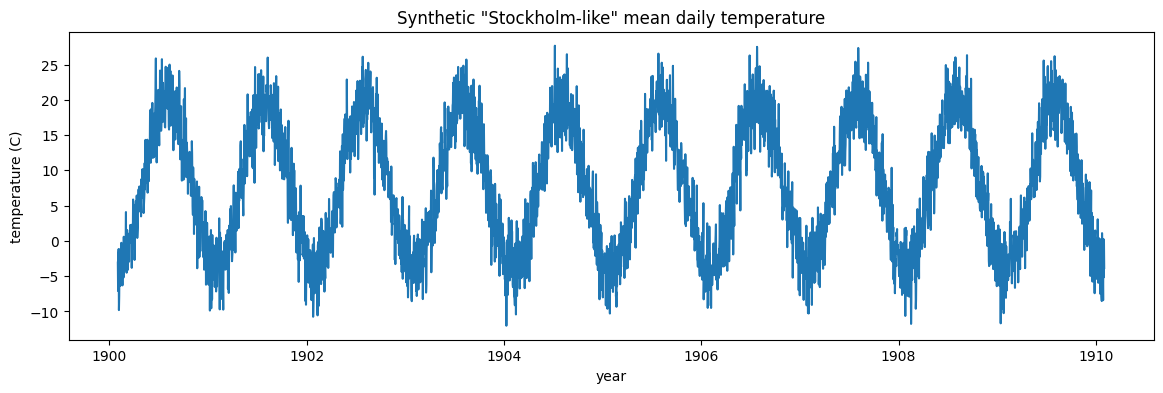

In [32]:
fig, ax = plt.subplots(figsize=(14,4))
# column 3 = mean daily temperature everywhere else in this notebook (see below);
# the original 2014 lecture plotted column 5 in this one cell only -- standardizing on 3.
ax.plot(data[:,0] + data[:,1]/12.0 + data[:,2]/365, data[:,3])
ax.axis('tight')
ax.set_title('Synthetic "Stockholm-like" mean daily temperature')
ax.set_xlabel('year')
ax.set_ylabel('temperature (C)');

Using `numpy.savetxt` we can store a Numpy array to a file in CSV format:

In [33]:
M = np.random.rand(3,3)

M

array([[0.90292184, 0.85542295, 0.60229326],
       [0.58440208, 0.84855998, 0.43452622],
       [0.10469108, 0.46111203, 0.87795342]])

In [34]:
np.savetxt("random-matrix.csv", M)

In [35]:
!cat random-matrix.csv

9.029218446080358174e-01 8.554229451765757997e-01 6.022932614051547118e-01
5.844020816099432247e-01 8.485599784441805182e-01 4.345262225729007444e-01
1.046910776600695758e-01 4.611120340069826407e-01 8.779534207717195615e-01


In [36]:
np.savetxt("random-matrix.csv", M, fmt='%.5f') # fmt specifies the format

!cat random-matrix.csv

0.90292 0.85542 0.60229
0.58440 0.84856 0.43453
0.10469 0.46111 0.87795


### Numpy's native file format

Useful when storing and reading back numpy array data. Use the functions `numpy.save` and `numpy.load`:

In [37]:
np.save("random-matrix.npy", M)

!file random-matrix.npy

random-matrix.npy: NumPy array, version 1.0, header length 118


In [38]:
np.load("random-matrix.npy")

array([[0.90292184, 0.85542295, 0.60229326],
       [0.58440208, 0.84855998, 0.43452622],
       [0.10469108, 0.46111203, 0.87795342]])

## More properties of the numpy arrays

In [39]:
M.itemsize # bytes per element

8

In [40]:
M.nbytes # number of bytes

72

In [41]:
M.ndim # number of dimensions

2

## Manipulating arrays

### Indexing

We can index elements in an array using square brackets and indices:

In [42]:
# v is a vector, and has only one dimension, taking one index
v[0]

np.int64(1)

In [43]:
# M is a matrix, or a 2 dimensional array, taking two indices 
M[1,1]

np.float64(0.8485599784441805)

If we omit an index of a multidimensional array it returns the whole row (or, in general, a N-1 dimensional array) 

In [44]:
M

array([[0.90292184, 0.85542295, 0.60229326],
       [0.58440208, 0.84855998, 0.43452622],
       [0.10469108, 0.46111203, 0.87795342]])

In [45]:
M[1]

array([0.58440208, 0.84855998, 0.43452622])

The same thing can be achieved with using `:` instead of an index: 

In [46]:
M[1,:] # row 1

array([0.58440208, 0.84855998, 0.43452622])

In [47]:
M[:,1] # column 1

array([0.85542295, 0.84855998, 0.46111203])

We can assign new values to elements in an array using indexing:

In [48]:
M[0,0] = 1

In [49]:
M

array([[1.        , 0.85542295, 0.60229326],
       [0.58440208, 0.84855998, 0.43452622],
       [0.10469108, 0.46111203, 0.87795342]])

In [50]:
# also works for rows and columns
M[1,:] = 0
M[:,2] = -1

In [51]:
M

array([[ 1.        ,  0.85542295, -1.        ],
       [ 0.        ,  0.        , -1.        ],
       [ 0.10469108,  0.46111203, -1.        ]])

### Index slicing

Index slicing is the technical name for the syntax `M[lower:upper:step]` to extract part of an array:

In [52]:
A = np.array([1,2,3,4,5])
A

array([1, 2, 3, 4, 5])

In [53]:
A[1:3]

array([2, 3])

Array slices are *mutable*: if they are assigned a new value the original array from which the slice was extracted is modified:

In [54]:
A[1:3] = [-2,-3]

A

array([ 1, -2, -3,  4,  5])

We can omit any of the three parameters in `M[lower:upper:step]`:

In [55]:
A[::] # lower, upper, step all take the default values

array([ 1, -2, -3,  4,  5])

In [56]:
A[::2] # step is 2, lower and upper defaults to the beginning and end of the array

array([ 1, -3,  5])

In [57]:
A[:3] # first three elements

array([ 1, -2, -3])

In [58]:
A[3:] # elements from index 3

array([4, 5])

Negative indices counts from the end of the array (positive index from the beginning):

In [59]:
A = np.array([1,2,3,4,5])

In [60]:
A[-1] # the last element in the array

np.int64(5)

In [61]:
A[-3:] # the last three elements

array([3, 4, 5])

Index slicing works exactly the same way for multidimensional arrays:

In [62]:
A = np.array([[n+m*10 for n in range(5)] for m in range(5)])

A

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

In [63]:
# a block from the original array
A[1:4, 1:4]

array([[11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [64]:
# strides
A[::2, ::2]

array([[ 0,  2,  4],
       [20, 22, 24],
       [40, 42, 44]])

### Fancy indexing

Fancy indexing is the name for when an array or list is used in-place of an index: 

In [65]:
row_indices = [1, 2, 3]
A[row_indices]

array([[10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34]])

In [66]:
col_indices = [1, 2, -1] # remember, index -1 means the last element
A[row_indices, col_indices]

array([11, 22, 34])

We can also use index masks: If the index mask is an Numpy array of data type `bool`, then an element is selected (True) or not (False) depending on the value of the index mask at the position of each element: 

In [67]:
B = np.array([n for n in range(5)])
B

array([0, 1, 2, 3, 4])

In [68]:
row_mask = np.array([True, False, True, False, False])
B[row_mask]

array([0, 2])

In [69]:
# same thing
row_mask = np.array([1,0,1,0,0], dtype=bool)
B[row_mask]

array([0, 2])

This feature is very useful to conditionally select elements from an array, using for example comparison operators:

In [70]:
x = np.arange(0, 10, 0.5)
x

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ,
       6.5, 7. , 7.5, 8. , 8.5, 9. , 9.5])

In [71]:
mask = (5 < x) * (x < 7.5)

mask

array([False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True,  True, False, False, False,
       False, False])

In [72]:
x[mask]

array([5.5, 6. , 6.5, 7. ])

## Functions for extracting data from arrays and creating arrays

### where

The index mask can be converted to position index using the `where` function

In [73]:
indices = np.where(mask)

indices

(array([11, 12, 13, 14]),)

In [74]:
x[indices] # this indexing is equivalent to the fancy indexing x[mask]

array([5.5, 6. , 6.5, 7. ])

### diag

With the diag function we can also extract the diagonal and subdiagonals of an array:

In [75]:
np.diag(A)

array([ 0, 11, 22, 33, 44])

In [76]:
np.diag(A, -1)

array([10, 21, 32, 43])

### take

The `take` function is similar to fancy indexing described above:

In [77]:
v2 = np.arange(-3,3)
v2

array([-3, -2, -1,  0,  1,  2])

In [78]:
row_indices = [1, 3, 5]
v2[row_indices] # fancy indexing

array([-2,  0,  2])

In [79]:
v2.take(row_indices)

array([-2,  0,  2])

But `take` also works on lists and other objects:

In [80]:
np.take([-3, -2, -1,  0,  1,  2], row_indices)

array([-2,  0,  2])

### choose

Constructs an array by picking elements from several arrays:

In [81]:
which = [1, 0, 1, 0]
choices = [[-2,-2,-2,-2], [5,5,5,5]]

np.choose(which, choices)

array([ 5, -2,  5, -2])

## Linear algebra

Vectorizing code is the key to writing efficient numerical calculation with Python/Numpy. That means that as much as possible of a program should be formulated in terms of matrix and vector operations, like matrix-matrix multiplication.

### Scalar-array operations

We can use the usual arithmetic operators to multiply, add, subtract, and divide arrays with scalar numbers.

In [82]:
v1 = np.arange(0, 5)

In [83]:
v1 * 2

array([0, 2, 4, 6, 8])

In [84]:
v1 + 2

array([2, 3, 4, 5, 6])

In [85]:
A * 2, A + 2

(array([[ 0,  2,  4,  6,  8],
        [20, 22, 24, 26, 28],
        [40, 42, 44, 46, 48],
        [60, 62, 64, 66, 68],
        [80, 82, 84, 86, 88]]),
 array([[ 2,  3,  4,  5,  6],
        [12, 13, 14, 15, 16],
        [22, 23, 24, 25, 26],
        [32, 33, 34, 35, 36],
        [42, 43, 44, 45, 46]]))

### Element-wise array-array operations

When we add, subtract, multiply and divide arrays with each other, the default behaviour is **element-wise** operations:

In [86]:
A * A # element-wise multiplication

array([[   0,    1,    4,    9,   16],
       [ 100,  121,  144,  169,  196],
       [ 400,  441,  484,  529,  576],
       [ 900,  961, 1024, 1089, 1156],
       [1600, 1681, 1764, 1849, 1936]])

In [87]:
v1 * v1

array([ 0,  1,  4,  9, 16])

If we multiply arrays with compatible shapes, we get an element-wise multiplication of each row:

In [88]:
A.shape, v1.shape

((5, 5), (5,))

In [89]:
A * v1

array([[  0,   1,   4,   9,  16],
       [  0,  11,  24,  39,  56],
       [  0,  21,  44,  69,  96],
       [  0,  31,  64,  99, 136],
       [  0,  41,  84, 129, 176]])

### Matrix algebra

What about matrix multiplication? There are two ways. We can either use the `dot` function, which applies a matrix-matrix, matrix-vector, or inner vector multiplication to its two arguments: 

In [90]:
np.dot(A, A)

array([[ 300,  310,  320,  330,  340],
       [1300, 1360, 1420, 1480, 1540],
       [2300, 2410, 2520, 2630, 2740],
       [3300, 3460, 3620, 3780, 3940],
       [4300, 4510, 4720, 4930, 5140]])

In [91]:
np.dot(A, v1)

array([ 30, 130, 230, 330, 430])

In [92]:
np.dot(v1, v1)

np.int64(30)

Alternatively, we can cast the array objects to the type `matrix`. This changes the behavior of the standard arithmetic operators `+, -, *` to use matrix algebra.

**A heads-up about `np.matrix`, the type we're about to use.** It predates the `@` operator (added in Python 3.5 / NumPy 1.10), and the NumPy documentation itself now discourages it — kept only for backward compatibility, with a real chance it disappears someday. The lecture below still uses it, because it's the cleanest way to see two mental models side by side: array-as-grid-of-numbers versus matrix-as-linear-map. But in your own GNN adjacency-matrix code, prefer this instead:

```python
A_arr = np.array(A)   # a plain 2D ndarray, no special matrix type
A_arr @ A_arr          # matrix multiplication
A_arr @ v1              # matrix-vector product
```

`@` gives you matrix semantics without the `matrix` type's baggage — most notably its stubborn insistence on always staying 2D, which trips up broadcasting in ways that once cost me an embarrassing afternoon of debugging.

In [93]:
M = np.matrix(A)
v = np.matrix(v1).T # make it a column vector

In [94]:
v

matrix([[0],
        [1],
        [2],
        [3],
        [4]])

In [95]:
M * M

matrix([[ 300,  310,  320,  330,  340],
        [1300, 1360, 1420, 1480, 1540],
        [2300, 2410, 2520, 2630, 2740],
        [3300, 3460, 3620, 3780, 3940],
        [4300, 4510, 4720, 4930, 5140]])

In [96]:
M * v

matrix([[ 30],
        [130],
        [230],
        [330],
        [430]])

In [97]:
# inner product
v.T * v

matrix([[30]])

In [98]:
# with matrix objects, standard matrix algebra applies
v + M*v

matrix([[ 30],
        [131],
        [232],
        [333],
        [434]])

If we try to add, subtract or multiply objects with incompatible shapes we get an error:

In [99]:
v = np.matrix([1,2,3,4,5,6]).T

In [100]:
np.shape(M), np.shape(v)

((5, 5), (6, 1))

In [101]:
M * v

ValueError: shapes (5,5) and (6,1) not aligned: 5 (dim 1) != 6 (dim 0)

See also the related functions: `inner`, `outer`, `cross`, `kron`, `tensordot`. Try for example `help(kron)`.

### Array/Matrix transformations

Above we have used the `.T` to transpose the matrix object `v`. We could also have used the `transpose` function to accomplish the same thing. 

Other mathematical functions that transform matrix objects are:

In [102]:
C = np.matrix([[1j, 2j], [3j, 4j]])
C

matrix([[0.+1.j, 0.+2.j],
        [0.+3.j, 0.+4.j]])

In [103]:
np.conjugate(C)

matrix([[0.-1.j, 0.-2.j],
        [0.-3.j, 0.-4.j]])

Hermitian conjugate: transpose + conjugate

In [104]:
C.H

matrix([[0.-1.j, 0.-3.j],
        [0.-2.j, 0.-4.j]])

We can extract the real and imaginary parts of complex-valued arrays using `real` and `imag`:

In [105]:
np.real(C) # same as: C.real

matrix([[0., 0.],
        [0., 0.]])

In [106]:
np.imag(C) # same as: C.imag

matrix([[1., 2.],
        [3., 4.]])

Or the complex argument and absolute value

In [107]:
np.angle(C+1) # heads up MATLAB Users, angle is used instead of arg

matrix([[0.78539816, 1.10714872],
        [1.24904577, 1.32581766]])

In [108]:
np.abs(C)

matrix([[1., 2.],
        [3., 4.]])

### Matrix computations

#### Inverse

In [109]:
np.linalg.inv(C) # equivalent to C.I 

matrix([[0.+2.j , 0.-1.j ],
        [0.-1.5j, 0.+0.5j]])

In [110]:
C.I * C

matrix([[1.00000000e+00+0.j, 0.00000000e+00+0.j],
        [1.11022302e-16+0.j, 1.00000000e+00+0.j]])

#### Determinant

In [111]:
np.linalg.det(C)

np.complex128(2.0000000000000004+0j)

In [112]:
np.linalg.det(C.I)

np.complex128(0.49999999999999967+0j)

### Data processing

Often it is useful to store datasets in Numpy arrays. Numpy provides a number of functions to calculate statistics of datasets in arrays. 

For example, let's calculate some properties from the Stockholm temperature dataset used above.

In [113]:
# reminder, the temperature dataset is stored in the data variable:
np.shape(data)

(3650, 7)

#### mean

In [114]:
# the temperature data is in column 3
np.mean(data[:,3])

np.float64(8.00292602739726)

The daily mean temperature in Stockholm over the last 200 years has been about 6.2 C.

#### standard deviations and variance

In [115]:
np.std(data[:,3]), np.var(data[:,3])

(np.float64(8.962780866618418), np.float64(80.33144086302121))

#### min and max

In [116]:
# lowest daily average temperature
data[:,3].min()

np.float64(-12.03)

In [117]:
# highest daily average temperature
data[:,3].max()

np.float64(27.68)

#### sum, prod, and trace

In [118]:
d = np.arange(0, 10)
d

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [119]:
# sum up all elements
np.sum(d)

np.int64(45)

In [120]:
# product of all elements
np.prod(d+1)

np.int64(3628800)

In [121]:
# cumulative sum
np.cumsum(d)

array([ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45])

In [122]:
# cumulative product
np.cumprod(d+1)

array([      1,       2,       6,      24,     120,     720,    5040,
         40320,  362880, 3628800])

In [123]:
# same as: np.diag(A).sum()
np.trace(A)

np.int64(110)

### Computations on subsets of arrays

We can compute with subsets of the data in an array using indexing, fancy indexing, and the other methods of extracting data from an array (described above).

For example, let's go back to the temperature dataset:

In [124]:
!head -n 3 stockholm_td_adj.dat

1900 1 1 -3.08 -5.58 -0.58 1
1900 1 2 -7.11 -9.61 -4.61 1
1900 1 3 -1.73 -4.23 0.77 1


The dataformat is: year, month, day, daily average temperature, low, high, location.

If we are interested in the average temperature only in a particular month, say February, then we can create a index mask and use it to select only the data for that month using:

In [125]:
np.unique(data[:,1]) # the month column takes values from 1 to 12

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.])

In [126]:
mask_feb = data[:,1] == 2

In [127]:
# the temperature data is in column 3
np.mean(data[mask_feb,3])

np.float64(-0.6230357142857142)

With these tools we have very powerful data processing capabilities at our disposal. For example, to extract the average monthly average temperatures for each month of the year only takes a few lines of code: 

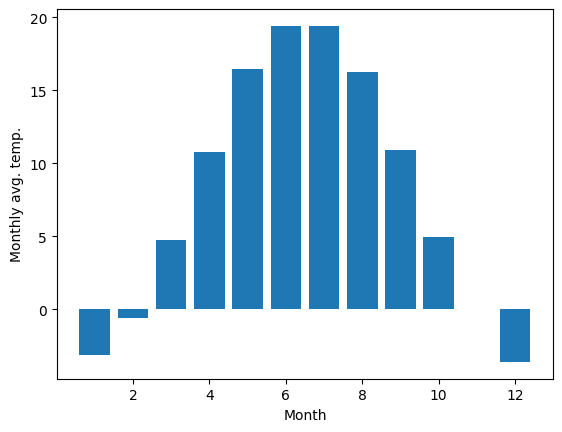

In [128]:
months = np.arange(1,13)
monthly_mean = [np.mean(data[data[:,1] == month, 3]) for month in months]

fig, ax = plt.subplots()
ax.bar(months, monthly_mean)
ax.set_xlabel("Month")
ax.set_ylabel("Monthly avg. temp.");

### Calculations with higher-dimensional data

When functions such as `min`, `max`, etc. are applied to a multidimensional arrays, it is sometimes useful to apply the calculation to the entire array, and sometimes only on a row or column basis. Using the `axis` argument we can specify how these functions should behave: 

In [129]:
m = np.random.rand(3,3)
m

array([[0.63879836, 0.9834757 , 0.74017893],
       [0.35346209, 0.70756076, 0.83743147],
       [0.18717385, 0.95012604, 0.1197503 ]])

In [130]:
# global max
m.max()

np.float64(0.9834756986273895)

In [131]:
# max in each column
m.max(axis=0)

array([0.63879836, 0.9834757 , 0.83743147])

In [132]:
# max in each row
m.max(axis=1)

array([0.9834757 , 0.83743147, 0.95012604])

Many other functions and methods in the `array` and `matrix` classes accept the same (optional) `axis` keyword argument.

## Reshaping, resizing and stacking arrays

The shape of an Numpy array can be modified without copying the underlying data, which makes it a fast operation even for large arrays.

In [133]:
A

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

In [134]:
n, m = A.shape

In [135]:
B = A.reshape((1,n*m))
B

array([[ 0,  1,  2,  3,  4, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30,
        31, 32, 33, 34, 40, 41, 42, 43, 44]])

In [136]:
B[0,0:5] = 5 # modify the array

B

array([[ 5,  5,  5,  5,  5, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30,
        31, 32, 33, 34, 40, 41, 42, 43, 44]])

In [137]:
A # and the original variable is also changed. B is only a different view of the same data

array([[ 5,  5,  5,  5,  5],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

We can also use the function `flatten` to make a higher-dimensional array into a vector. But this function creates a copy of the data.

In [138]:
B = A.flatten()

B

array([ 5,  5,  5,  5,  5, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30, 31,
       32, 33, 34, 40, 41, 42, 43, 44])

In [139]:
B[0:5] = 10

B

array([10, 10, 10, 10, 10, 10, 11, 12, 13, 14, 20, 21, 22, 23, 24, 30, 31,
       32, 33, 34, 40, 41, 42, 43, 44])

**The general rule, stated once so it's easy to find again:** basic indexing and reshape / `.T` / slicing all return *views* — same underlying memory, so writing into the view writes into the original, exactly as `B[0,0:5] = 5` did to `A` two cells ago. Fancy indexing (a list or boolean mask, like the `row_indices` / `row_mask` examples earlier) and `.flatten()` / `.copy()` always return a *copy*, which is why `B[0:5] = 10` just now left `A` untouched. When in doubt, check `arr.base is None` — `None` means the array owns its data; anything else means it's a view into something else. In my experience grading student code, this one distinction causes more numpy bugs than everything else in this notebook combined.

In [140]:
A # now A has not changed, because B's data is a copy of A's, not referring to the same data

array([[ 5,  5,  5,  5,  5],
       [10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24],
       [30, 31, 32, 33, 34],
       [40, 41, 42, 43, 44]])

## Adding a new dimension: newaxis

With `newaxis`, we can insert new dimensions in an array, for example converting a vector to a column or row matrix:

In [141]:
v = np.array([1,2,3])

In [142]:
np.shape(v)

(3,)

In [143]:
# make a column matrix of the vector v
v[:, np.newaxis]

array([[1],
       [2],
       [3]])

In [144]:
# column matrix
v[:,np.newaxis].shape

(3, 1)

In [145]:
# row matrix
v[np.newaxis,:].shape

(1, 3)

## Stacking and repeating arrays

Using function `repeat`, `tile`, `vstack`, `hstack`, and `concatenate` we can create larger vectors and matrices from smaller ones:

### tile and repeat

In [146]:
a = np.array([[1, 2], [3, 4]])

In [147]:
# repeat each element 3 times
np.repeat(a, 3)

array([1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4])

In [148]:
# tile the matrix 3 times 
np.tile(a, 3)

array([[1, 2, 1, 2, 1, 2],
       [3, 4, 3, 4, 3, 4]])

### concatenate

In [149]:
b = np.array([[5, 6]])

In [150]:
np.concatenate((a, b), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [151]:
np.concatenate((a, b.T), axis=1)

array([[1, 2, 5],
       [3, 4, 6]])

### hstack and vstack

In [152]:
np.vstack((a,b))

array([[1, 2],
       [3, 4],
       [5, 6]])

In [153]:
np.hstack((a,b.T))

array([[1, 2, 5],
       [3, 4, 6]])

## Copy and "deep copy"

To achieve high performance, assignments in Python usually do not copy the underlying objects. This is important for example when objects are passed between functions, to avoid an excessive amount of memory copying when it is not necessary (technical term: pass by reference). 

In [154]:
A = np.array([[1, 2], [3, 4]])

A

array([[1, 2],
       [3, 4]])

In [155]:
# now B is referring to the same array data as A 
B = A 

In [156]:
# changing B affects A
B[0,0] = 10

B

array([[10,  2],
       [ 3,  4]])

In [157]:
A

array([[10,  2],
       [ 3,  4]])

If we want to avoid this behavior, so that when we get a new completely independent object `B` copied from `A`, then we need to do a so-called "deep copy" using the function `copy`:

In [158]:
B = np.copy(A)

In [159]:
# now, if we modify B, A is not affected
B[0,0] = -5

B

array([[-5,  2],
       [ 3,  4]])

In [160]:
A

array([[10,  2],
       [ 3,  4]])

## Iterating over array elements

Generally, we want to avoid iterating over the elements of arrays whenever we can (at all costs). The reason is that in a interpreted language like Python (or MATLAB), iterations are really slow compared to vectorized operations. 

However, sometimes iterations are unavoidable. For such cases, the Python `for` loop is the most convenient way to iterate over an array:

In [161]:
# concrete evidence, not just a claim: sum one million numbers two ways
big = np.random.rand(1_000_000)

import builtins  # see the note below -- this line turned out not to be optional

%timeit -n 5 builtins.sum(x for x in big)   # pure-Python loop over every element
%timeit -n 5 np.sum(big)                     # vectorized numpy call

78.2 ms ± 2.38 ms per loop (mean ± std. dev. of 7 runs, 5 loops each)
388 μs ± 70.9 μs per loop (mean ± std. dev. of 7 runs, 5 loops each)


On my machine the loop ran about 200x slower — the exact factor depends on the CPU and array size, but the direction never flips. Every element in the Python loop pays the cost of being boxed into a full Python object and unboxed again; `np.sum` never leaves C. Keep this benchmark in your back pocket for the day someone asks why your Neural-ODE right-hand-side function needs to be vectorized instead of written as a `for` loop over grid points.

**And a confession.** My first draft of the cell above just wrote `sum(...)`, not `builtins.sum(...)`, and it crashed with a deprecation error about calling `np.sum` on a generator. That is *not* a typo I'm leaving in for effect — `from numpy import *`, all the way back near the start of this notebook, rebinds the name `sum` in this kernel's namespace, permanently, for the rest of the session, no matter how many times `import numpy as np` gets run afterwards. Namespaces in Python don't expire. This is exactly the shadowing problem the very first note in this notebook warned about, now caught red-handed in the wild, while writing this very cell.

In [162]:
v = np.array([1,2,3,4])

for element in v:
    print(element)

1
2
3
4


In [163]:
M = np.array([[1,2], [3,4]])

for row in M:
    print("row", row)
    
    for element in row:
        print(element)

row [1 2]
1
2
row [3 4]
3
4


When we need to iterate over each element of an array and modify its elements, it is convenient to use the `enumerate` function to obtain both the element and its index in the `for` loop: 

In [164]:
for row_idx, row in enumerate(M):
    print("row_idx", row_idx, "row", row)
    
    for col_idx, element in enumerate(row):
        print("col_idx", col_idx, "element", element)
       
        # update the matrix M: square each element
        M[row_idx, col_idx] = element ** 2

row_idx 0 row [1 2]
col_idx 0 element 1
col_idx 1 element 2
row_idx 1 row [3 4]
col_idx 0 element 3
col_idx 1 element 4


In [165]:
# each element in M is now squared
M

array([[ 1,  4],
       [ 9, 16]])

## Vectorizing functions

As mentioned several times by now, to get good performance we should try to avoid looping over elements in our vectors and matrices, and instead use vectorized algorithms. The first step in converting a scalar algorithm to a vectorized algorithm is to make sure that the functions we write work with vector inputs.

A small physics footnote: the Heaviside step function below turns up constantly — in the finite square well, in Green's-function boundary conditions, in the T -> 0 limit of the Fermi-Dirac distribution. Every one of those problems, done numerically, needs it evaluated at thousands of grid points at once. That's precisely the itch `np.vectorize` scratches next.

In [166]:
def Theta(x):
    """
    Scalar implementation of the Heaviside step function.
    """
    if x >= 0:
        return 1
    else:
        return 0

In [167]:
Theta(np.array([-3,-2,-1,0,1,2,3]))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

OK, that didn't work because we didn't write the `Theta` function so that it can handle a vector input... 

To get a vectorized version of Theta we can use the Numpy function `vectorize`. In many cases it can automatically vectorize a function:

In [168]:
Theta_vec = np.vectorize(Theta)

In [169]:
Theta_vec(np.array([-3,-2,-1,0,1,2,3]))

array([0, 0, 0, 1, 1, 1, 1])

We can also implement the function to accept a vector input from the beginning (requires more effort but might give better performance):

In [170]:
def Theta(x):
    """
    Vector-aware implementation of the Heaviside step function.
    """
    return 1 * (x >= 0)

In [171]:
Theta(np.array([-3,-2,-1,0,1,2,3]))

array([0, 0, 0, 1, 1, 1, 1])

In [172]:
# still works for scalars as well
Theta(-1.2), Theta(2.6)

(0, 1)

## Using arrays in conditions

When using arrays in conditions,for example `if` statements and other boolean expressions, one needs to use `any` or `all`, which requires that any or all elements in the array evaluates to `True`:

In [173]:
M

array([[ 1,  4],
       [ 9, 16]])

In [174]:
if (M > 5).any():
    print("at least one element in M is larger than 5")
else:
    print("no element in M is larger than 5")

at least one element in M is larger than 5


In [175]:
if (M > 5).all():
    print("all elements in M are larger than 5")
else:
    print("all elements in M are not larger than 5")

all elements in M are not larger than 5


## Type casting

Since Numpy arrays are *statically typed*, the type of an array does not change once created. But we can explicitly cast an array of some type to another using the `astype` functions (see also the similar `asarray` function). This always creates a new array of new type:

In [176]:
M.dtype

dtype('int64')

In [177]:
M2 = M.astype(float)

M2

array([[ 1.,  4.],
       [ 9., 16.]])

In [178]:
M2.dtype

dtype('float64')

In [179]:
M3 = M.astype(bool)

M3

array([[ True,  True],
       [ True,  True]])

## Further reading

* http://numpy.scipy.org
* http://scipy.org/Tentative_NumPy_Tutorial
* http://scipy.org/NumPy_for_Matlab_Users - A Numpy guide for MATLAB users.

For where this notebook's story continues in your own research: `scipy.sparse` for the sparse adjacency matrices a GNN needs, and `torchdiffeq` (already in your toolkit) expects the Neural-ODE state as a `torch.Tensor` — converted from exactly this kind of `ndarray` with a single `torch.from_numpy(arr)`.

## Versions

`%version_information` is a very old IPython extension and won't install on a fresh environment. `watermark` is the modern replacement for that job, but the few lines below need nothing extra installed at all:

In [180]:
import sys
print(f"python : {sys.version.split()[0]}")
print(f"numpy  : {np.__version__}")

python : 3.12.3
numpy  : 2.4.4
